In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


In [2]:
img = cv.imread('img/rice.tif', cv.IMREAD_GRAYSCALE)

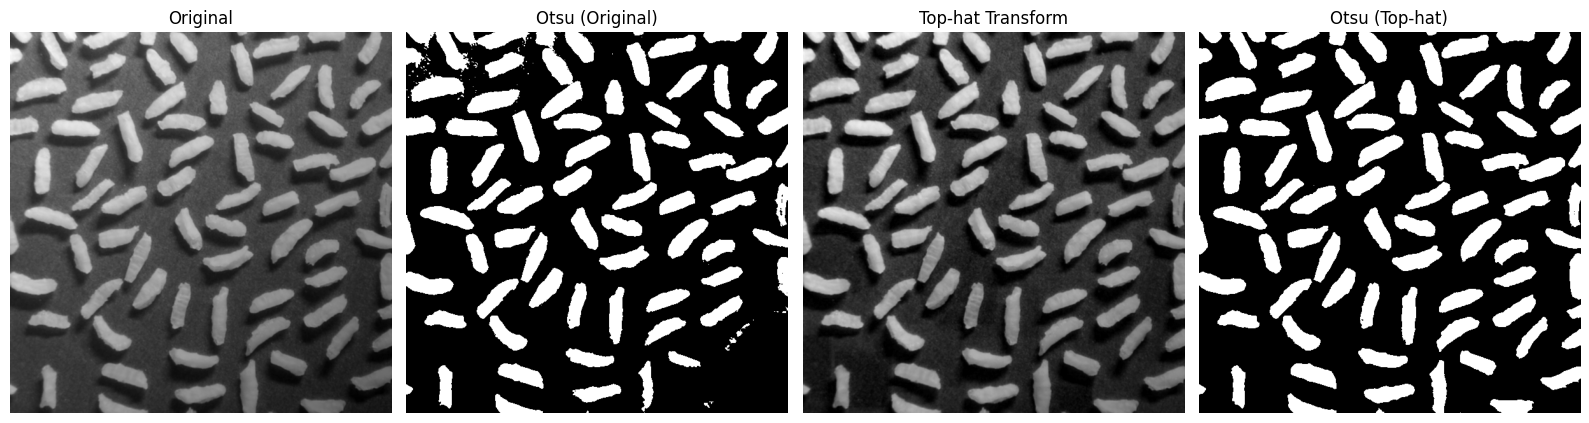

In [ ]:
# 원본 영상에 대한 Otsu 이진화
ret1, thresh_original = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Top-hat 변환 수행
kernel = cv.getStructuringElement(cv.MORPH_RECT, (81, 81)) 
# kernel = cv.getStructuringElement(cv.MORPH_RECT, (9,9)) 
# kernel = cv.getStructuringElement(cv.MORPH_RECT, (7,7)) 
# kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (11, 11))
tophat = cv.morphologyEx(img, cv.MORPH_TOPHAT, kernel)

# Top-hat 결과 영상에 대한 Otsu 이진화
ret2, thresh_tophat = cv.threshold(tophat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

titles = ['Original', 'Otsu (Original)', 'Top-hat Transform', 'Otsu (Top-hat)']
images = [img, thresh_original, tophat, thresh_tophat]

plt.figure(figsize=(16, 8))
for i in range(4):
    plt.subplot(1,4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


Ostu 단독 이진화는 일부 그림자 더 강한 곳에 있는 쌀이 제거되는 경향을 보인다. 

Top-hat 변환은 원본보다 더 선명한 상태로 화질을 개선했으며   
Ostu 이진화를 진행했을 때 기존에는 보이지 않았던 쌀이 유지되었다. 